# 0. ИМПОРТЫ

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. ЗАГРУЗКА ДАННЫХ

In [ ]:
dataset_path = "/root/.cache/kagglehub/datasets/jmmvutu/ecommerce-users-of-a-french-c2c-fashion-store/versions/6"
file_path = os.path.join(dataset_path, 'users.6M0xxK.2024.public.csv')
df = pd.read_csv(file_path)

print(f"Загружено {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Загружено 20743 строк, 21 столбцов


,identifierHash,type,countryCode,country,language,socialNbFollowers,socialNbFollows,socialProductsLiked,productsListed,productsSold,...,productsWished,productsBought,gender,civilityGenderId,civilityTitle,hasProfilePicture,seniority,seniorityAsMonths,seniorityAsYears,websiteLongevity
0,1920991140,user,us,Etats-Unis,en,3,8,0,0,0,...,0,0,M,1,mr,True,3206,106.87,8.91,3803
1,1920860068,user,se,Suède,en,3,8,1,0,0,...,0,0,M,1,mr,True,3206,106.87,8.91,3803
2,1920401316,user,it,Italie,fr,3,8,0,0,0,...,0,0,M,1,mr,True,3206,106.87,8.91,3803
3,1919811492,user,dk,Danemark,en,75,10,1968,0,0,...,43,15,M,1,mr,True,3206,106.87,8.91,3803
4,1919025060,user,de,Allemagne,de,3,8,0,0,0,...,0,0,M,1,mr,True,3206,106.87,8.91,3803


# 2. ПЕРВИЧНЫЙ ОСМОТР

In [ ]:
print("\nИнформация о типах данных:")
df.info()

print("\nСтатистика числовых признаков:")
df.describe()

print("\nПропуски:")
print(df.isnull().sum())


Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20743 entries, 0 to 20742
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   identifierHash       20743 non-null  int64  
 1   type                 20743 non-null  object 
 2   countryCode          20710 non-null  object 
 3   country              20743 non-null  object 
 4   language             20743 non-null  object 
 5   socialNbFollowers    20743 non-null  int64  
 6   socialNbFollows      20743 non-null  int64  
 7   socialProductsLiked  20743 non-null  int64  
 8   productsListed       20743 non-null  int64  
 9   productsSold         20743 non-null  int64  
 10  productsPassRate     20743 non-null  float64
 11  productsWished       20743 non-null  int64  
 12  productsBought       20743 non-null  int64  
 13  gender               20743 non-null  object 
 14  civilityGenderId     20743 non-null  int64  
 15  civility

In [ ]:
# Проверка дубликатов

duplicates = df.duplicated().sum()

print(f"\nКоличество совпадающих записей после удаления технических полей: {duplicates}")

# Для задачи сегментации пользователей записи не удаляем.
# Разные пользователи могут иметь одинаковые характеристики поведения.
print(f"\nПосле чистки: {df.shape[0]} строк, {df.shape[1]} столбцов")


Количество совпадающих записей после удаления технических полей: 0

После чистки: 20743 строк, 21 столбцов


# 3. ЧИСТКА ДАННЫХ

In [ ]:
# 3.1 Удаляем константные признаки
constant_features = []
for col in df.columns:
    if df[col].nunique() <= 1:
        constant_features.append(col)
        print(f"  Константный признак: {col} (значение: {df[col].iloc[0]})")

  Константный признак: type (значение: user)
  Константный признак: gender (значение: M)
  Константный признак: civilityGenderId (значение: 1)
  Константный признак: civilityTitle (значение: mr)
  Константный признак: websiteLongevity (значение: 3803)


In [ ]:
# 3.2 Удаляем бесполезные признаки
columns_to_drop = [
    'identifierHash',    # Идентификатор
    'type',              # Все 'user'
    'gender',            # Все 'M'
    'civilityGenderId',  # Все 1
    'civilityTitle',     # Все 'mr'
    'websiteLongevity',  # Все 3803
    'seniority',         # Дублирует seniorityAsYears
    'seniorityAsMonths', # Дублирует seniorityAsYears
    'countryCode'        # Дублирует country
]

columns_to_drop = [col for col in columns_to_drop if col in df.columns]
print(f"\nУдаляем {len(columns_to_drop)} признаков:")
for col in columns_to_drop:
    print(f"  - {col}")

df = df.drop(columns=columns_to_drop)


Удаляем 9 признаков:
  - identifierHash
  - type
  - gender
  - civilityGenderId
  - civilityTitle
  - websiteLongevity
  - seniority
  - seniorityAsMonths
  - countryCode


# 4. ОПИСАНИЕ ПРИЗНАКОВ ДЛЯ EDA

ПОВЕДЕНЧЕСКИЕ ПРИЗНАКИ:
  - productsListed: товары на продажу
  - productsSold: проданные товары
  - productsBought: купленные товары
  - productsWished: товары в желаемом
  - productsPassRate: % успешных продаж
  - socialProductsLiked: лайки на товары

СОЦИАЛЬНЫЕ ПРИЗНАКИ:
  - socialNbFollowers: подписчики
  - socialNbFollows: подписки

ДЕМОГРАФИЧЕСКИЕ ПРИЗНАКИ:
  - country: страна
  - language: язык

ЛОЯЛЬНОСТЬ:
  - seniorityAsYears: стаж в годах
  - hasProfilePicture: наличие фото

# EDA - РАЗВЕДОЧНЫЙ АНАЛИЗ


--------------------------------------------------
ТОП-5 СТРАН
--------------------------------------------------


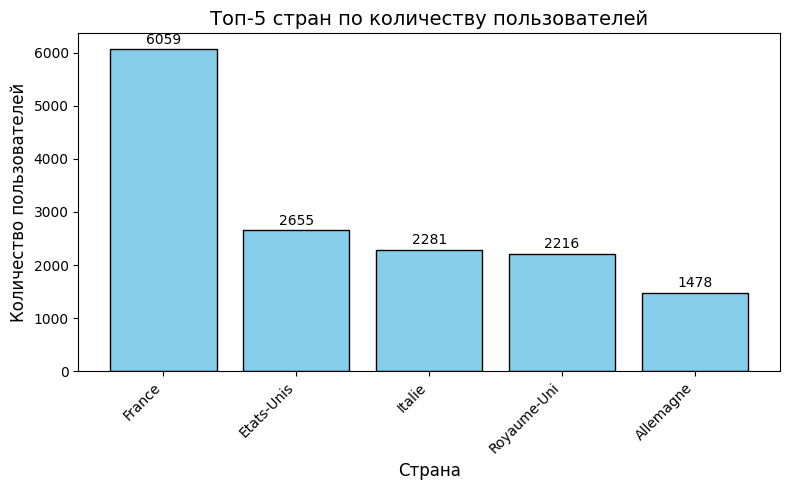


Топ-5 стран:
  France: 6059 пользователей (29.2%)
  Etats-Unis: 2655 пользователей (12.8%)
  Italie: 2281 пользователей (11.0%)
  Royaume-Uni: 2216 пользователей (10.7%)
  Allemagne: 1478 пользователей (7.1%)


In [ ]:
# 5.1 Топ-5 стран
print("\n" + "-"*50)
print("ТОП-5 СТРАН")
print("-"*50)

top_countries = df['country'].value_counts().head(5)

plt.figure(figsize=(8, 5))
bars = plt.bar(top_countries.index, top_countries.values,
               color='skyblue', edgecolor='black')
plt.title('Топ-5 стран по количеству пользователей', fontsize=14)
plt.xlabel('Страна', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nТоп-5 стран:")
for country, count in top_countries.items():
    print(f"  {country}: {count} пользователей ({count/len(df)*100:.1f}%)")



--------------------------------------------------
РАСПРЕДЕЛЕНИЕ ПОКУПОК
--------------------------------------------------


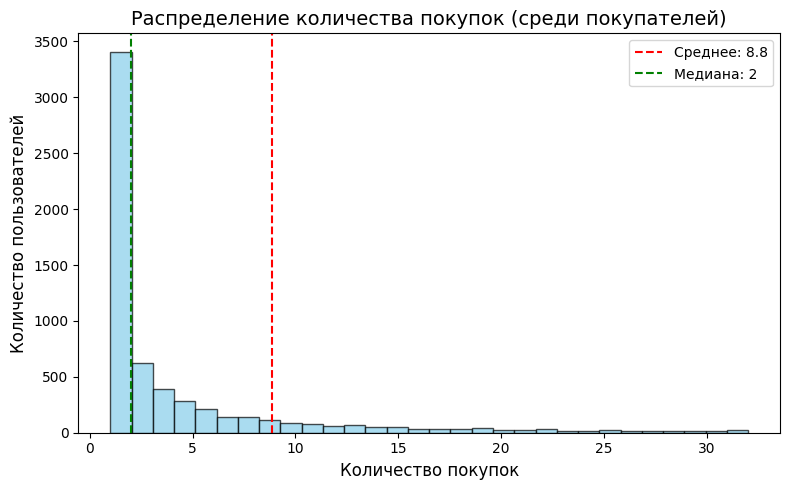


Статистика по покупкам:
  Всего покупателей: 6384 человек (30.8%)
  Среднее: 8.85
  Медиана: 2
  Максимум: 2679


In [ ]:
# 5.2 Распределение покупок
print("\n" + "-"*50)
print("РАСПРЕДЕЛЕНИЕ ПОКУПОК")
print("-"*50)

buyers = df[df['productsBought'] > 0]
q95 = buyers['productsBought'].quantile(0.95)
buyers_filtered = buyers[buyers['productsBought'] <= q95]

plt.figure(figsize=(8, 5))
plt.hist(buyers_filtered['productsBought'], bins=30, edgecolor='black',
         alpha=0.7, color='skyblue')
plt.axvline(buyers['productsBought'].mean(), color='red', linestyle='--',
            label=f'Среднее: {buyers["productsBought"].mean():.1f}')
plt.axvline(buyers['productsBought'].median(), color='green', linestyle='--',
            label=f'Медиана: {buyers["productsBought"].median():.0f}')
plt.title('Распределение количества покупок (среди покупателей)', fontsize=14)
plt.xlabel('Количество покупок', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nСтатистика по покупкам:")
print(f"  Всего покупателей: {len(buyers)} человек ({len(buyers)/len(df)*100:.1f}%)")
print(f"  Среднее: {buyers['productsBought'].mean():.2f}")
print(f"  Медиана: {buyers['productsBought'].median():.0f}")
print(f"  Максимум: {buyers['productsBought'].max()}")


--------------------------------------------------
РАСПРЕДЕЛЕНИЕ ПРОДАЖ
--------------------------------------------------


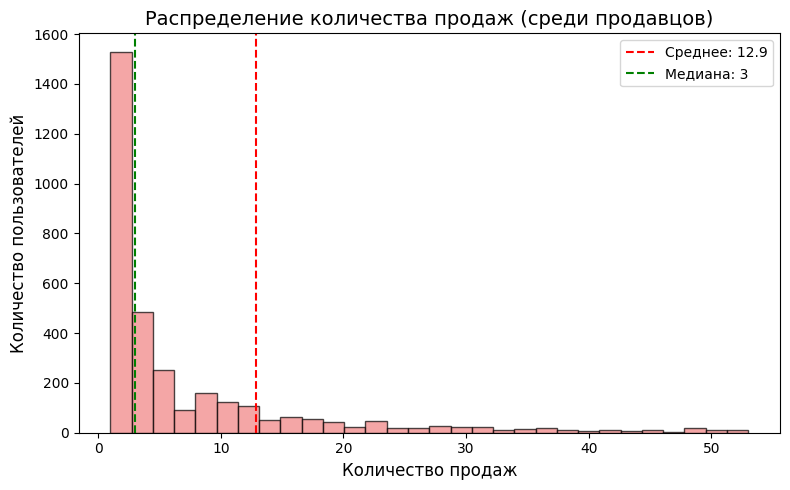


Статистика по продажам:
  Всего продавцов: 3436 человек (16.6%)
  Среднее: 12.88
  Медиана: 3
  Максимум: 843


In [ ]:
# 5.3 Распределение продаж
print("\n" + "-"*50)
print("РАСПРЕДЕЛЕНИЕ ПРОДАЖ")
print("-"*50)

sellers = df[df['productsSold'] > 0]
q95 = sellers['productsSold'].quantile(0.95)
sellers_filtered = sellers[sellers['productsSold'] <= q95]

plt.figure(figsize=(8, 5))
plt.hist(sellers_filtered['productsSold'], bins=30, edgecolor='black',
         alpha=0.7, color='lightcoral')
plt.axvline(sellers['productsSold'].mean(), color='red', linestyle='--',
            label=f'Среднее: {sellers["productsSold"].mean():.1f}')
plt.axvline(sellers['productsSold'].median(), color='green', linestyle='--',
            label=f'Медиана: {sellers["productsSold"].median():.0f}')
plt.title('Распределение количества продаж (среди продавцов)', fontsize=14)
plt.xlabel('Количество продаж', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nСтатистика по продажам:")
print(f"  Всего продавцов: {len(sellers)} человек ({len(sellers)/len(df)*100:.1f}%)")
print(f"  Среднее: {sellers['productsSold'].mean():.2f}")
print(f"  Медиана: {sellers['productsSold'].median():.0f}")
print(f"  Максимум: {sellers['productsSold'].max()}")



--------------------------------------------------
РАСПРЕДЕЛЕНИЕ СТАЖА
--------------------------------------------------


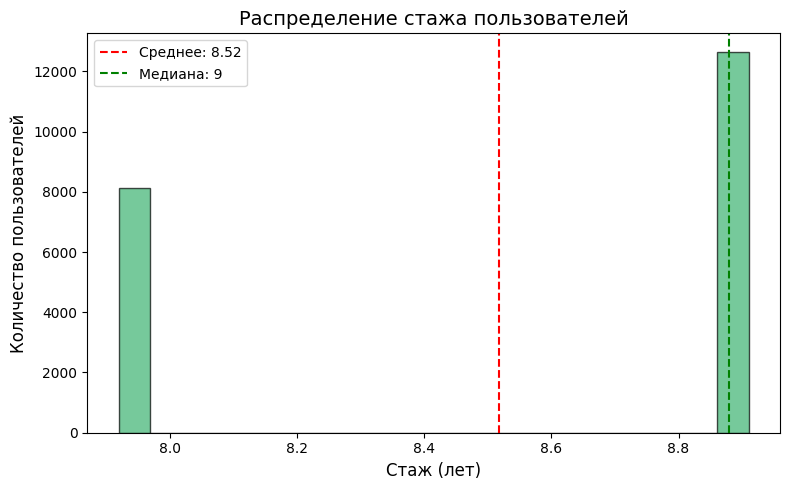


Статистика по стажу:
  Средний: 8.52 лет
  Минимальный: 7.92 лет
  Максимальный: 8.91 лет


In [ ]:
# 5.4 Распределение стажа
print("\n" + "-"*50)
print("РАСПРЕДЕЛЕНИЕ СТАЖА")
print("-"*50)

plt.figure(figsize=(8, 5))
plt.hist(df['seniorityAsYears'], bins=20, edgecolor='black',
         alpha=0.7, color='mediumseagreen')
plt.axvline(df['seniorityAsYears'].mean(), color='red', linestyle='--',
            label=f'Среднее: {df["seniorityAsYears"].mean():.2f}')
plt.axvline(df['seniorityAsYears'].median(), color='green', linestyle='--',
            label=f'Медиана: {df["seniorityAsYears"].median():.0f}')
plt.title('Распределение стажа пользователей', fontsize=14)
plt.xlabel('Стаж (лет)', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nСтатистика по стажу:")
print(f"  Средний: {df['seniorityAsYears'].mean():.2f} лет")
print(f"  Минимальный: {df['seniorityAsYears'].min():.2f} лет")
print(f"  Максимальный: {df['seniorityAsYears'].max():.2f} лет")



--------------------------------------------------
РАСПРЕДЕЛЕНИЕ ПО СТРАНАМ
--------------------------------------------------


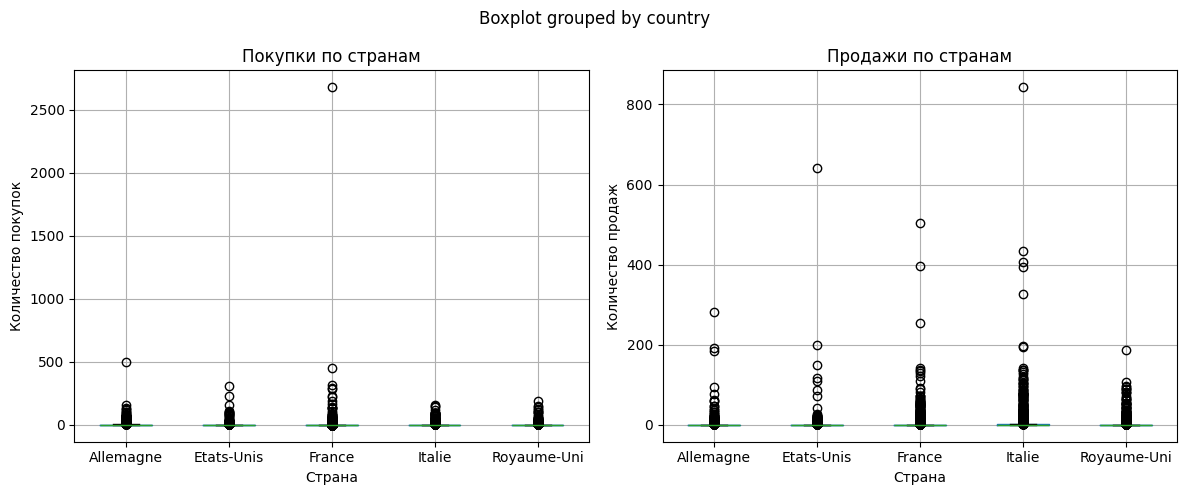

In [ ]:
# 5.5 Boxplot по странам
print("\n" + "-"*50)
print("РАСПРЕДЕЛЕНИЕ ПО СТРАНАМ")
print("-"*50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

top5_countries = df['country'].value_counts().head(5).index
df_top5 = df[df['country'].isin(top5_countries)]

df_top5.boxplot(column='productsBought', by='country', ax=axes[0])
axes[0].set_title('Покупки по странам', fontsize=12)
axes[0].set_xlabel('Страна', fontsize=10)
axes[0].set_ylabel('Количество покупок', fontsize=10)

df_top5.boxplot(column='productsSold', by='country', ax=axes[1])
axes[1].set_title('Продажи по странам', fontsize=12)
axes[1].set_xlabel('Страна', fontsize=10)
axes[1].set_ylabel('Количество продаж', fontsize=10)

plt.tight_layout()
plt.show()



--------------------------------------------------
СОЦИАЛЬНЫЕ ПРИЗНАКИ
--------------------------------------------------


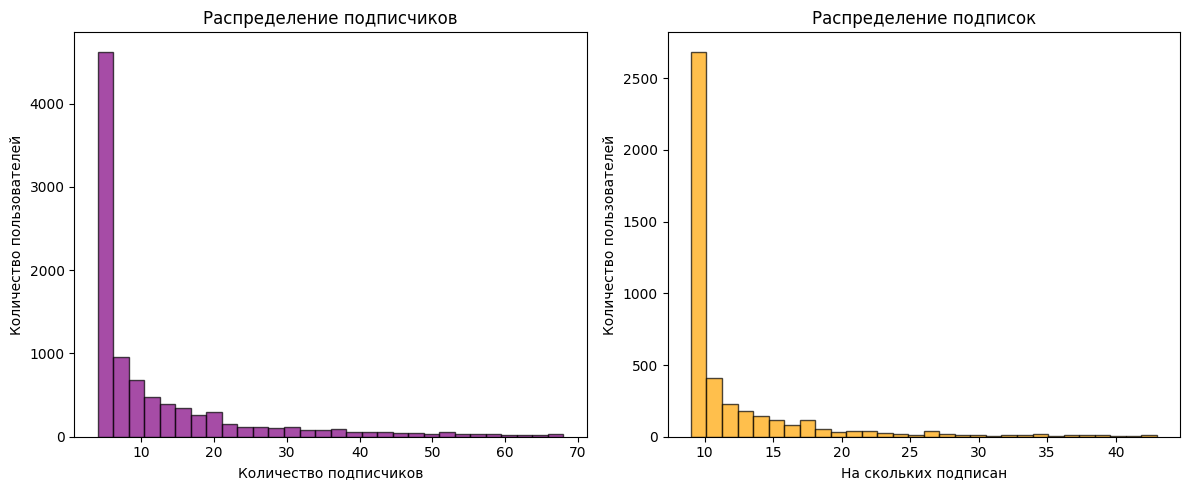


Статистика по подписчикам:
  Среднее: 11.3
  Медиана: 3
  Максимум: 4134

Статистика по подпискам:
  Среднее: 15.6
  Медиана: 8
  Максимум: 71045


In [ ]:
# 5.6 Социальные признаки
print("\n" + "-"*50)
print("СОЦИАЛЬНЫЕ ПРИЗНАКИ")
print("-"*50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

followers = df[df['socialNbFollowers'] > 3]
followers_filtered = followers[followers['socialNbFollowers'] <= followers['socialNbFollowers'].quantile(0.95)]

axes[0].hist(followers_filtered['socialNbFollowers'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[0].set_title('Распределение подписчиков', fontsize=12)
axes[0].set_xlabel('Количество подписчиков', fontsize=10)
axes[0].set_ylabel('Количество пользователей', fontsize=10)

follows = df[df['socialNbFollows'] > 8]
follows_filtered = follows[follows['socialNbFollows'] <= follows['socialNbFollows'].quantile(0.95)]

axes[1].hist(follows_filtered['socialNbFollows'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Распределение подписок', fontsize=12)
axes[1].set_xlabel('На скольких подписан', fontsize=10)
axes[1].set_ylabel('Количество пользователей', fontsize=10)

plt.tight_layout()
plt.show()

print("\nСтатистика по подписчикам:")
print(f"  Среднее: {df['socialNbFollowers'].mean():.1f}")
print(f"  Медиана: {df['socialNbFollowers'].median():.0f}")
print(f"  Максимум: {df['socialNbFollowers'].max()}")

print("\nСтатистика по подпискам:")
print(f"  Среднее: {df['socialNbFollows'].mean():.1f}")
print(f"  Медиана: {df['socialNbFollows'].median():.0f}")
print(f"  Максимум: {df['socialNbFollows'].max()}")


--------------------------------------------------
ЛАЙКИ И ЖЕЛАЕМЫЕ ТОВАРЫ
--------------------------------------------------


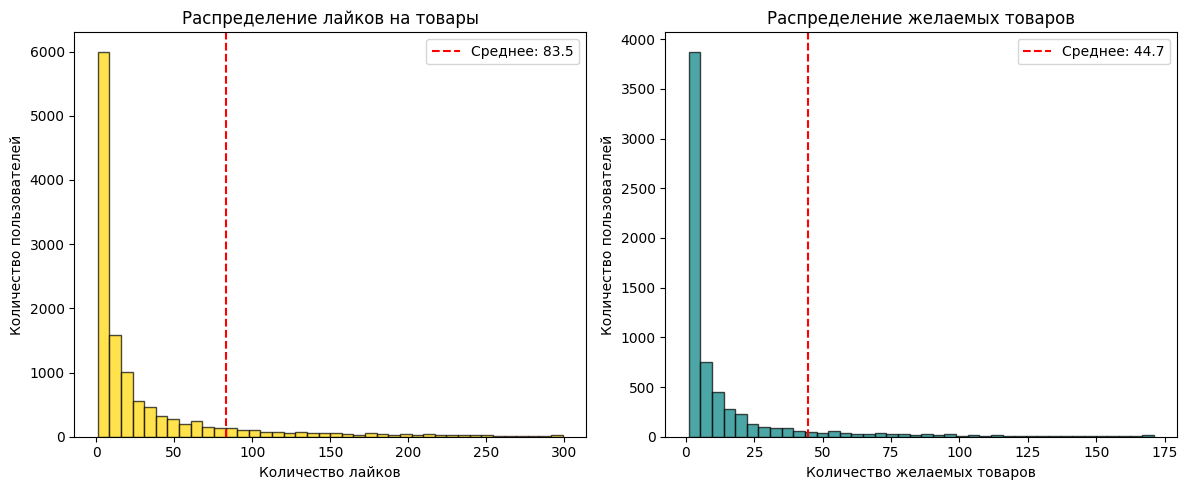


Статистика по лайкам:
  Пользователи с лайками: 12888 человек (62.1%)
  Среднее: 83.5

Статистика по желаемым товарам:
  Пользователи с желаемым: 6974 человек (33.6%)
  Среднее: 44.7


In [ ]:
# 5.7 Лайки и желаемое
print("\n" + "-"*50)
print("ЛАЙКИ И ЖЕЛАЕМЫЕ ТОВАРЫ")
print("-"*50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

likes = df[df['socialProductsLiked'] > 0]
likes_filtered = likes[likes['socialProductsLiked'] <= likes['socialProductsLiked'].quantile(0.95)]

axes[0].hist(likes_filtered['socialProductsLiked'], bins=40, edgecolor='black', alpha=0.7, color='gold')
axes[0].axvline(likes['socialProductsLiked'].mean(), color='red', linestyle='--',
            label=f'Среднее: {likes["socialProductsLiked"].mean():.1f}')
axes[0].set_title('Распределение лайков на товары', fontsize=12)
axes[0].set_xlabel('Количество лайков', fontsize=10)
axes[0].set_ylabel('Количество пользователей', fontsize=10)
axes[0].legend()

wished = df[df['productsWished'] > 0]
wished_filtered = wished[wished['productsWished'] <= wished['productsWished'].quantile(0.95)]

axes[1].hist(wished_filtered['productsWished'], bins=40, edgecolor='black', alpha=0.7, color='teal')
axes[1].axvline(wished['productsWished'].mean(), color='red', linestyle='--',
            label=f'Среднее: {wished["productsWished"].mean():.1f}')
axes[1].set_title('Распределение желаемых товаров', fontsize=12)
axes[1].set_xlabel('Количество желаемых товаров', fontsize=10)
axes[1].set_ylabel('Количество пользователей', fontsize=10)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nСтатистика по лайкам:")
print(f"  Пользователи с лайками: {len(likes)} человек ({len(likes)/len(df)*100:.1f}%)")
print(f"  Среднее: {likes['socialProductsLiked'].mean():.1f}")

print("\nСтатистика по желаемым товарам:")
print(f"  Пользователи с желаемым: {len(wished)} человек ({len(wished)/len(df)*100:.1f}%)")
print(f"  Среднее: {wished['productsWished'].mean():.1f}")


--------------------------------------------------
УСПЕШНОСТЬ ПРОДАЖ
--------------------------------------------------


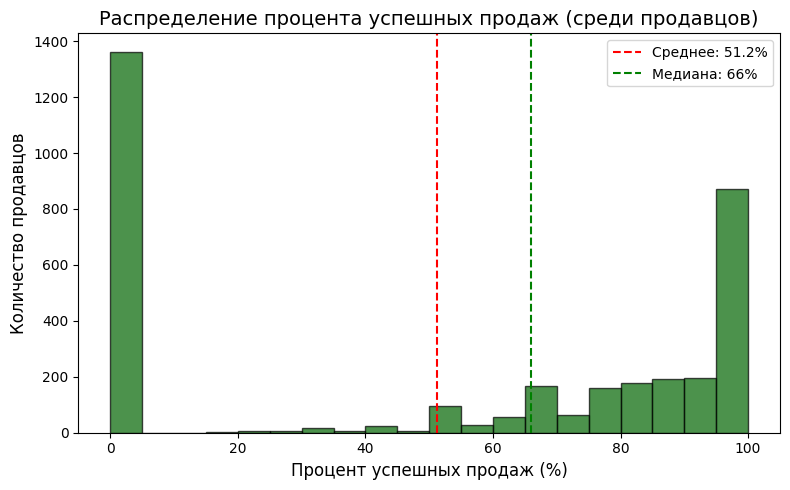


Статистика по успешности продаж:
  Среднее: 51.2%
  Медиана: 66%
  100% успешность: 779 человек


In [ ]:
# 5.8 Успешность продаж
print("\n" + "-"*50)
print("УСПЕШНОСТЬ ПРОДАЖ")
print("-"*50)

sellers = df[df['productsSold'] > 0]

plt.figure(figsize=(8, 5))
plt.hist(sellers['productsPassRate'], bins=20, edgecolor='black', alpha=0.7, color='darkgreen')
plt.axvline(sellers['productsPassRate'].mean(), color='red', linestyle='--',
            label=f'Среднее: {sellers["productsPassRate"].mean():.1f}%')
plt.axvline(sellers['productsPassRate'].median(), color='green', linestyle='--',
            label=f'Медиана: {sellers["productsPassRate"].median():.0f}%')
plt.title('Распределение процента успешных продаж (среди продавцов)', fontsize=14)
plt.xlabel('Процент успешных продаж (%)', fontsize=12)
plt.ylabel('Количество продавцов', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print("\nСтатистика по успешности продаж:")
print(f"  Среднее: {sellers['productsPassRate'].mean():.1f}%")
print(f"  Медиана: {sellers['productsPassRate'].median():.0f}%")
print(f"  100% успешность: {len(sellers[sellers['productsPassRate'] == 100])} человек")


--------------------------------------------------
ФОТО ПРОФИЛЯ
--------------------------------------------------


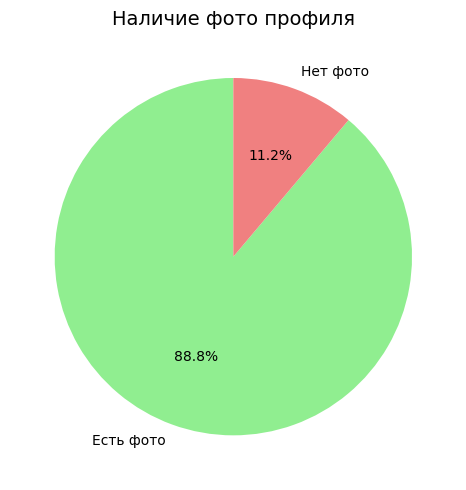


Пользователи с фото: 18430 человек (88.8%)
Пользователи без фото: 2313 человек (11.2%)


In [ ]:
# 5.9 Фото профиля
print("\n" + "-"*50)
print("ФОТО ПРОФИЛЯ")
print("-"*50)

photo_counts = df['hasProfilePicture'].value_counts()
labels = ['Есть фото', 'Нет фото']
colors = ['lightgreen', 'lightcoral']

plt.figure(figsize=(6, 5))
plt.pie(photo_counts.values, labels=labels, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Наличие фото профиля', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nПользователи с фото: {photo_counts.get(True, 0)} человек ({photo_counts.get(True, 0)/len(df)*100:.1f}%)")
print(f"Пользователи без фото: {photo_counts.get(False, 0)} человек ({photo_counts.get(False, 0)/len(df)*100:.1f}%)")



--------------------------------------------------
ЯЗЫКИ ПОЛЬЗОВАТЕЛЕЙ
--------------------------------------------------


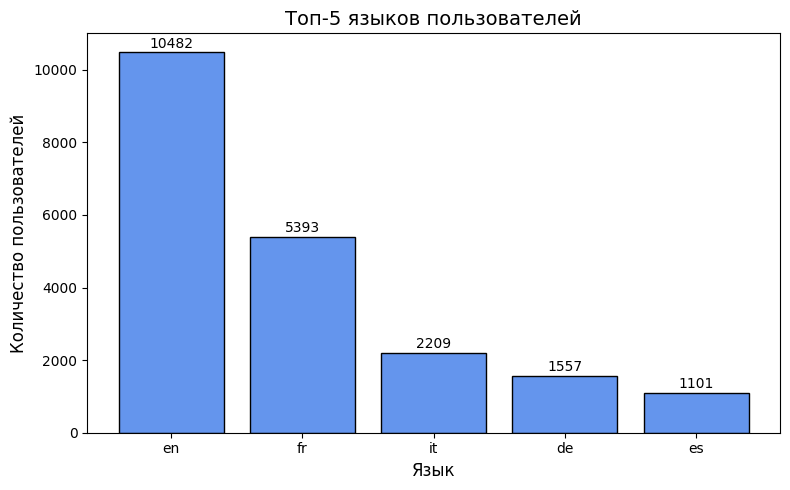


Топ-5 языков:
  en: 10482 пользователей (50.5%)
  fr: 5393 пользователей (26.0%)
  it: 2209 пользователей (10.6%)
  de: 1557 пользователей (7.5%)
  es: 1101 пользователей (5.3%)


In [ ]:
# 5.10 Языки
print("\n" + "-"*50)
print("ЯЗЫКИ ПОЛЬЗОВАТЕЛЕЙ")
print("-"*50)

top_languages = df['language'].value_counts().head(5)

plt.figure(figsize=(8, 5))
bars = plt.bar(top_languages.index, top_languages.values,
               color='cornflowerblue', edgecolor='black')
plt.title('Топ-5 языков пользователей', fontsize=14)
plt.xlabel('Язык', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nТоп-5 языков:")
for lang, count in top_languages.items():
    print(f"  {lang}: {count} пользователей ({count/len(df)*100:.1f}%)")


--------------------------------------------------
СВЯЗЬ ПОКУПОК И ПРОДАЖ
--------------------------------------------------


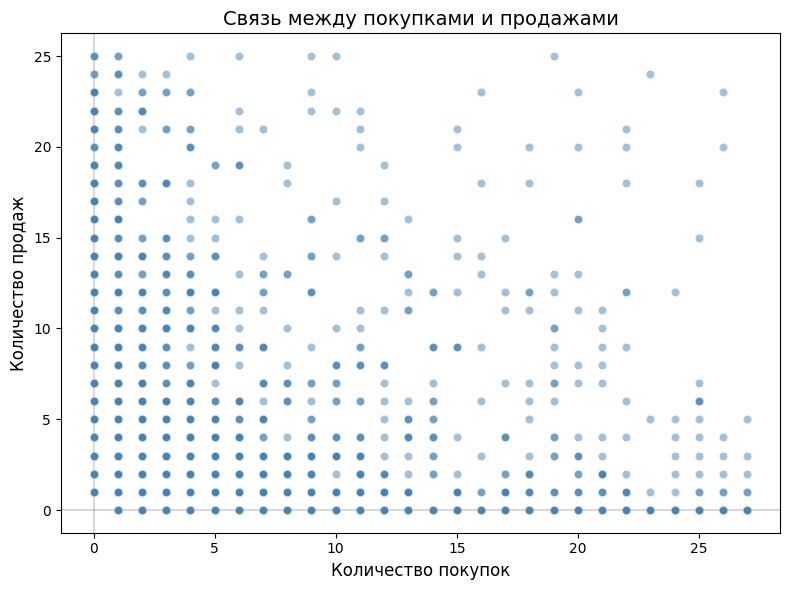


Интерпретация:
  Большинство пользователей покупают, но не продают
  Чем правее точка, тем больше покупок
  Чем выше точка, тем больше продаж


In [ ]:
# 5.11 Связь покупок и продаж
print("\n" + "-"*50)
print("СВЯЗЬ ПОКУПОК И ПРОДАЖ")
print("-"*50)

active = df[(df['productsBought'] > 0) | (df['productsSold'] > 0)]
active_filtered = active[
    (active['productsBought'] <= active['productsBought'].quantile(0.95)) &
    (active['productsSold'] <= active['productsSold'].quantile(0.95))
]

plt.figure(figsize=(8, 6))
plt.scatter(active_filtered['productsBought'], active_filtered['productsSold'],
            alpha=0.5, c='steelblue', edgecolors='white', linewidth=0.5)
plt.xlabel('Количество покупок', fontsize=12)
plt.ylabel('Количество продаж', fontsize=12)
plt.title('Связь между покупками и продажами', fontsize=14)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nИнтерпретация:")
print("  Большинство пользователей покупают, но не продают")
print("  Чем правее точка, тем больше покупок")
print("  Чем выше точка, тем больше продаж")


--------------------------------------------------
КОРРЕЛЯЦИОННАЯ МАТРИЦА
--------------------------------------------------


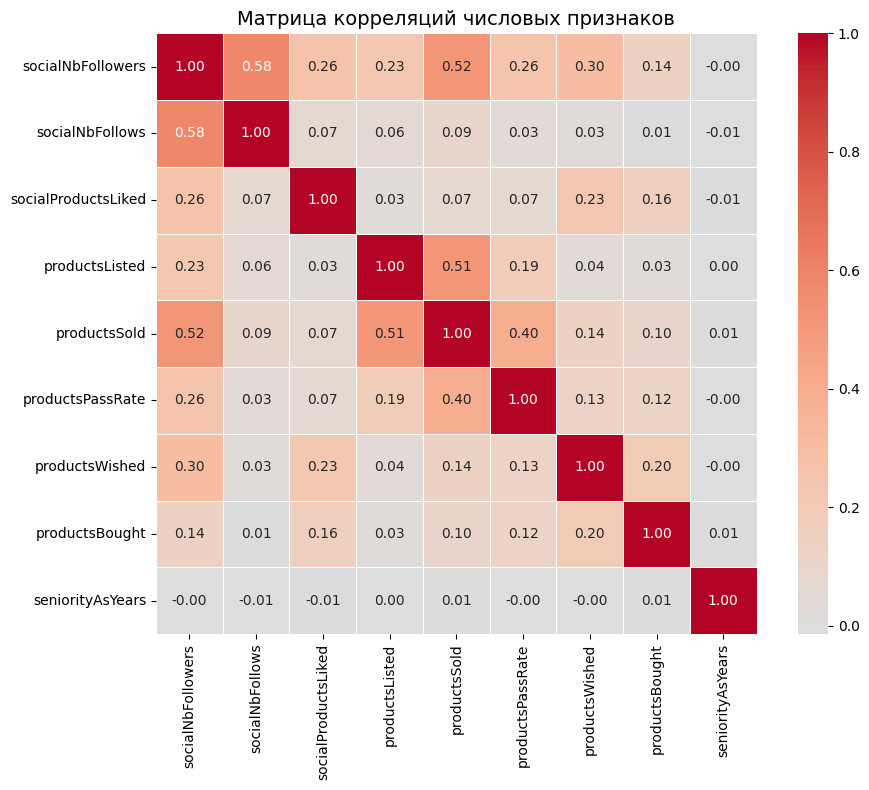


Сильные корреляции (|r| > 0.5):
  socialNbFollowers <-> socialNbFollows: 0.58
  socialNbFollowers <-> productsSold: 0.52
  productsListed <-> productsSold: 0.51


In [ ]:
# 5.12 Корреляционная матрица
print("\n" + "-"*50)
print("КОРРЕЛЯЦИОННАЯ МАТРИЦА")
print("-"*50)

numeric_cols = ['socialNbFollowers', 'socialNbFollows', 'socialProductsLiked',
                'productsListed', 'productsSold', 'productsPassRate',
                'productsWished', 'productsBought', 'seniorityAsYears']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Матрица корреляций числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

print("\nСильные корреляции (|r| > 0.5):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > 0.5:
            print(f"  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr:.2f}")
